### Exercise 1

Consider the distribution with PDF
$$
    p(x) = \begin{cases}
                \frac{1}{2}\sin x & 0 \le x \le \pi \\
                0 & \text{otherwise}
            \end{cases}
$$

1. Derive the CDF $F(x) = \int_{-\infty}^{x} p(x')\,\mathrm{d}x'$ analytically, and plot it together with the PDF $p(x)$.
2. Find the inverse CDF $F^{-1}(u)$, and use it to transform samples $U \sim \mathcal{U}(0, 1)$ into samples $X = F^{-1}(U)$ (inverse transform sampling).
3. Compare a density-normalised histogram of the samples with the PDF $p(x)$. 

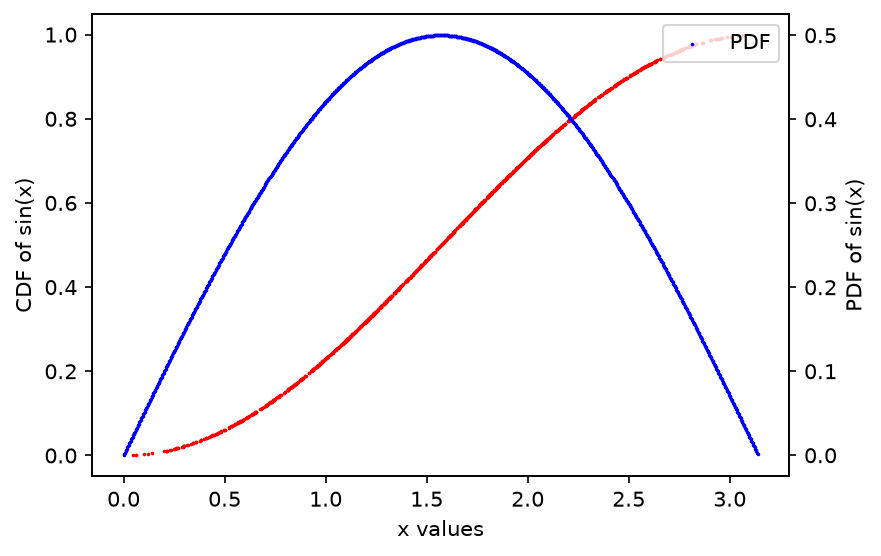

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

def inverse_Fu(u):
    u = np.asarray(u, dtype=float)
    return np.arccos(1-2*u)

rng = np.random.default_rng()

axis = []
cdf = []


for i in range(0,1000):
    y = rng.uniform(0,1)
    x = inverse_Fu(y)
    cdf.append(y)
    axis.append(x)


#print(np.array(cdf))

domain = np.arange(0, np.pi, step=np.pi/1000)

pdf = np.array([1/2*np.sin(i) for i in domain])

#print(pdf)

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=150)

ax1.scatter(axis, cdf, s=0.5, color="red", label="CDF")
ax1.set_xlabel("x values")
ax1.set_ylabel("CDF of sin(x)")
ax2 = ax1.twinx()
ax2.scatter(domain, pdf, s=0.5, color='blue', label='PDF')
ax2.set_ylabel('PDF of sin(x)')
#ax2.set_ylim(0,1)

plt.legend()

plt.show()



### Exercise 2

Consider a random variable with distribution $p(x)$, mean $\operatorname{E}[x] = \mu$ and variance $\operatorname{Var}[x] = \sigma^2$, and let $a$ and $c$ be constants. Using the definition of the expectation,
$$
    \operatorname{E}[f(x)] = \int_{-\infty}^\infty f(x)\, p(x)\,\mathrm{d}x \, ,
$$
show that:

**Mean**

1. $\operatorname{E}[x + a] = \mu + a$
2. $\operatorname{E}[cx] = c\mu$

**Variance**

3. $\operatorname{Var}[x] = \operatorname{E}[(x - \operatorname{E}[x])^2] = \operatorname{E}[x^2] - \operatorname{E}[x]^2$
4. $\operatorname{Var}[x + a] = \sigma^2$
5. $\operatorname{Var}[cx] = c^2\sigma^2$

*Hint:* use the linearity of the expectation (results 1 and 2) to prove results 3–5.

### Exercise 3

Let $X_1, \dots, X_n$ be $n$ i.i.d. random variables with $X_i \sim \mathcal{U}(0, 1)$, and let $K$ be the number of them that fall into a small interval of width $\Delta x$.

1. Confirm by simulation that, for large $n$ and small $\Delta x$ with the rate $\lambda = n\,\Delta x$ held fixed, $K$ follows a Poisson distribution:
$$
    \Pr(K = k) = \frac{\lambda^k}{k!}\mathrm{e}^{-\lambda}
$$
2. Derive the Poisson distribution from the binomial distribution, $\Pr(K = k) = \binom{n}{k}p^k(1-p)^{n-k}$, in the limit $n \to \infty$ with $np = \lambda$ held fixed.

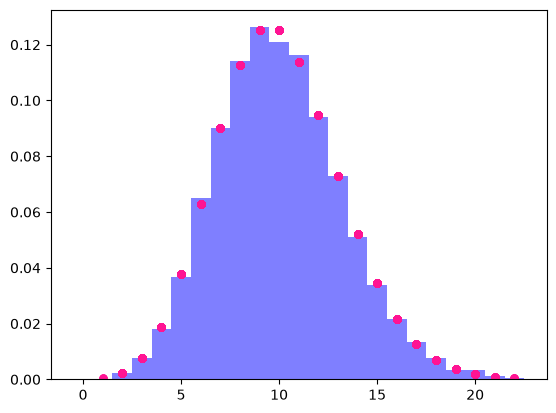

In [12]:
n_samples = 1000     # number of samples from uniform distribution
interval = 0.01             # Delta x
lamb = n_samples*interval      # lambda


n_iterations = 10000

# create array with 10000 runs, each populated with 1000 random variable evaluations
rv = rng.uniform(0,1, size=(n_iterations, n_samples))  


K = np.sum(rv < interval, axis=1)

#print(K)

k_bins= np.arange(24) - 0.5

plt.hist(K, bins=k_bins, alpha=0.5, density=True, color='blue')
plt.plot(K, ss.poisson(lamb).pmf(K), "o", color='deeppink', markersize=5)








We simulate a binomial counting experiment. Each experiment generates `n_samples = 1000` independent samples from $\mathcal{U}(0,1)$, i.e. $\mathbf{uniformly}$. A sample is counted when it falls below `interval = 0.01`, so the probability of being counted is $p=0.01$. The expected number of counted samples is therefore $\lambda = np = 1000(0.01)=10$.

`rv` has shape `(10000, 1000)`: each row represents one experiment. The comparison `rv < interval` creates Boolean values, and `np.sum(..., axis=1)` counts the `True` values in each row. Thus, `K` is a one-dimensional array of 10,000 counts. Exactly each count follows $\operatorname{Binomial}(1000,0.01)$, which is well approximated by $\operatorname{Poisson}(10)$.

The histogram displays the empirical distribution of these counts. The bin edges are shifted by $0.5$ so that integer outcomes are centered in their bins, and `density=True` normalizes the histogram to probability density values.

The final line is plotting the theoretical Poisson PMF.



### Exercise 4

1. Make plots of the PDFs of the distributions covered in the lecture, varying their parameters (e.g., vary one parameter at a time while keeping the others fixed: for the normal distribution, plot $\mathcal{N}(\mu, 1)$ for three values of $\mu$, and $\mathcal{N}(0, \sigma^2)$ for three values of $\sigma^2$). For discrete distributions, such as the binomial and Poisson, plot the PMF instead.
2. Compute the distribution of the sum $Z = X + Y$ of two independent Gaussian RVs $X \sim \mathcal{N}(\mu_X, \sigma_X^2)$ and $Y \sim \mathcal{N}(\mu_Y, \sigma_Y^2)$.
   *Hint:* the lecture states that sums of Gaussian RVs are Gaussian, and a Gaussian is completely determined by its mean and variance, so it is enough to compute $\operatorname{E}[Z]$ and $\operatorname{Var}[Z]$. Independence means that the joint PDF factorises, $p_{XY}(x, y) = p_X(x)\,p_Y(y)$.
3. What is the distribution of the sum $Z = X + Y$ of two independent RVs $X \sim p_X$ and $Y \sim p_Y$?
4. Derive the PDF of the $\chi^2_{\nu=1}$ distribution, i.e., of $Z = X^2$ with $X \sim \mathcal{N}(0, 1)$.

**Bonus**

5. What is the distribution of the product $Z = UV$ of two independent RVs $U$ and $V$?
6. Compute the distribution of the ratio of two independent Gaussian RVs.